In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

from keras import callbacks, layers, models

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping

2025-10-01 15:20:04.623530: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-01 15:20:04.721158: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-01 15:20:06.807719: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
# En local :
directory = ''

# Sur Google collab ou Onyxia (sur un répertoire temporaire) :
# directory = ''

# Sur Google collab (sur le drive) :
# from google.colab import drive
# drive.mount('/content/drive')
# directory = '/content/drive/MyDrive/Data/'

In [4]:
data = pd.read_csv(directory + 'ozone_complet.csv',
                   header    = 0,
                   # index_col = 0,
                   sep       = ';',
                   decimal   = ',')

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1464 entries, 0 to 1463
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    1464 non-null   int64  
 1   maxO3   1391 non-null   float64
 2   T6      1463 non-null   float64
 3   T9      1463 non-null   float64
 4   T12     1463 non-null   float64
 5   T15     1463 non-null   float64
 6   T18     1463 non-null   float64
 7   Ne6     1462 non-null   float64
 8   Ne9     1462 non-null   float64
 9   Ne12    1462 non-null   float64
 10  Ne15    1462 non-null   float64
 11  Ne18    1459 non-null   float64
 12  Vdir6   1463 non-null   float64
 13  Vvit6   1463 non-null   float64
 14  Vdir9   1463 non-null   float64
 15  Vvit9   1463 non-null   float64
 16  Vdir12  1463 non-null   float64
 17  Vvit12  1463 non-null   float64
 18  Vdir15  1463 non-null   float64
 19  Vvit15  1463 non-null   float64
 20  Vdir18  1463 non-null   float64
 21  Vvit18  1463 non-null   float64
 22  

In [6]:

data.head()

,date,maxO3,T6,T9,T12,T15,T18,Ne6,Ne9,Ne12,...,Vdir9,Vvit9,Vdir12,Vvit12,Vdir15,Vvit15,Vdir18,Vvit18,Vx,maxO3v
0,19950401,47.6,10.1,11.6,13.3,13.6,12.2,8.0,8.0,8.0,...,290.0,4.0,300.0,4.0,340.0,4.0,20.0,4.0,-3.4641,62.2
1,19950402,56.2,9.5,9.4,13.8,17.4,16.3,8.0,8.0,7.0,...,160.0,2.0,180.0,3.0,110.0,1.0,350.0,2.0,0.0000,47.6
2,19950403,61.8,3.6,8.0,16.8,21.5,20.2,4.0,5.0,2.0,...,20.0,2.0,340.0,1.0,170.0,2.0,170.0,3.0,-0.3420,56.2
3,19950404,50.8,9.5,10.5,11.4,12.2,11.4,8.0,7.0,7.0,...,10.0,4.0,350.0,3.0,350.0,3.0,350.0,4.0,-0.5209,61.8
4,19950405,59.8,9.8,10.8,13.8,14.3,13.3,8.0,7.0,8.0,...,340.0,2.0,280.0,1.0,320.0,3.0,350.0,4.0,-0.9848,50.8


In [7]:
data.dropna(inplace=True)

missing_percentage = data.isna().mean() * 100

print('MISSING VALUES :')
if missing_percentage[missing_percentage != 0].empty:
    print('No')
else:
    print(missing_percentage[missing_percentage != 0].sort_values(ascending=False))

MISSING VALUES :
No


In [8]:
target = 'maxO3'

y = data[target]
X = data.drop(target, axis=1)

In [9]:
test_portion  = 1/5
valid_portion = 1/5

X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size=test_portion)

X_train, X_valid, y_train, y_valid = train_test_split(X_train_valid, y_train_valid, test_size=valid_portion)

print('Dimensions de X_train :', X_train.shape)
print('Dimensions de X_valid :', X_valid.shape)
print('Dimensions de X_test  :', X_test.shape)

print('Dimensions de y_train :', y_train.shape)
print('Dimensions de y_valid :', y_valid.shape)
print('Dimensions de y_test  :', y_test.shape)

Dimensions de X_train : (873, 23)
Dimensions de X_valid : (219, 23)
Dimensions de X_test  : (274, 23)
Dimensions de y_train : (873,)
Dimensions de y_valid : (219,)
Dimensions de y_test  : (274,)


In [10]:
scaler = StandardScaler()
scaler.fit(X_train)

X_train_norm = scaler.transform(X_train)
X_valid_norm = scaler.transform(X_valid)
X_test_norm  = scaler.transform(X_test)

In [11]:
# Dimensions d'entrée et sortie
dim_inputs = (X_train_norm.shape[1],)
dim_outputs = 1  # régression sur une seule variable

# Architecture
n_units_hl1 = 50
n_units_hl2 = 30
dropout_hl1 = 0.2
dropout_hl2 = 0.2

# Définition du modèle
model = models.Sequential(name='DNN_regression')
model.add(layers.Input(shape=dim_inputs, name='Inputs'))
model.add(layers.Dense(units=n_units_hl1, activation='relu', name='Hidden_layer_1'))
model.add(layers.Dropout(rate=dropout_hl1, name='Dropout_HL1'))
model.add(layers.Dense(units=n_units_hl2, activation='relu', name='Hidden_layer_2'))
model.add(layers.Dropout(rate=dropout_hl2, name='Dropout_HL2'))
model.add(layers.Dense(units=dim_outputs, activation='linear', name='Output_layer'))

# Compilation : régression avec MSE
model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='mean_squared_error',
              metrics=['mean_squared_error'])

model.summary()

# Optionnel : EarlyStopping pour éviter surapprentissage
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Entraînement
history = model.fit(X_train_norm, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=1)


2025-10-01 15:20:07.275533: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "DNN_regression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_layer_1 (Dense)          │ (None, 50)             │         1,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_HL1 (Dropout)           │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Hidden_layer_2 (Dense)          │ (None, 30)             │         1,530 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_HL2 (Dropout)           │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_layer (Dense)            │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,761 (10.79 KB)

 Trainable params: 2,761 (10.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 7596.5532 - mean_squared_error: 7596.5532 - val_loss: 7134.0635 - val_mean_squared_error: 7134.0635
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 7266.4614 - mean_squared_error: 7266.4614 - val_loss: 6743.1899 - val_mean_squared_error: 6743.1899
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 6740.6704 - mean_squared_error: 6740.6704 - val_loss: 6061.0894 - val_mean_squared_error: 6061.0894
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 5843.7852 - mean_squared_error: 5843.7852 - val_loss: 4970.7637 - val_mean_squared_error: 4970.7637
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4506.5176 - mean_squared_error: 4506.5176 - val_loss: 3528.0710 - val_mean_squared_error: 3528.0710
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 3006.5225 - mean_squared_error: 3006.5225 - val_loss: 2092.8450 - val_mean_squared_error: 2092.8450
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/

In [12]:
# Évaluation sur test set
mse_test = model.evaluate(X_test_norm, y_test, verbose=0)
print(f"MSE sur test set : {mse_test[0]:.4f}")

# Prédictions
y_pred = model.predict(X_test_norm)

MSE sur test set : 231.9072
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


NameError: name 'hist' is not defined

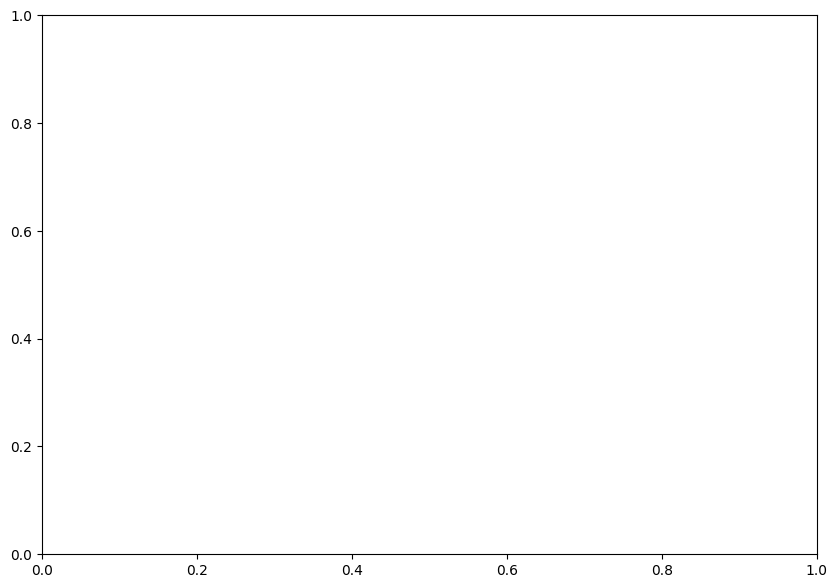

In [14]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(hist.history['loss'], label='Train')
ax.plot(hist.history['val_loss'], label='Validation')
ax.set_xlabel('Epoque')
ax.set_title('Entropie')
ax.legend(loc='best')
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([[1.],
       [1.],
       [1.],
       [1.],
       [1.]], dtype=float32)

array([[1],
       [1],
       [1],
       [1],
       [1]])

Entropie test   : -146606.6406
Exactitude test : 0.0000
